Load internal modules

In [1]:
from src.utils_datapreprocessing import StockAnalysis
from src.utils_loreal_cross_asset_features import CrossAssetFeatureEngineering
from src.utils_feature_engineering import FeatureEngineering
from src.utils_LSTM_model import LSTMModel
from src.utils_LSTM_trading_strategy import LSTMTradingStrategyBacktest

Specify your stock of choice: Loreal SA

In [2]:
ticker = 'OR.PA'
start_date = "2014-12-01"  # Start date 10 years prior to the end date
end_date = "2024-11-30" 
file_path = "cqf_e_Stock_data_2024_12_10_22_40_02.xlsx"
sheet_name = "LOREAL"
columns_to_merge = ["MarketValue", "DividendYield", "PriceToEarnings", "EPS", "PriceToCash", "PriceToBook"]
tickers = ["OR.PA", "LVMUY", "^SP500-30", "NESN.SW"]


Gather, plot data & EDA  - yfinance

In [3]:
Analysis = StockAnalysis(ticker, start_date, end_date, file_path, sheet_name, columns_to_merge)

In [4]:
Analysis.fetch_stock_data()

[*********************100%***********************]  1 of 1 completed


In [5]:
Analysis.process_excel_data()

In [6]:
Analysis.export_to_csv('merged_df_final.csv')

Data exported successfully as 'merged_df_final.csv'


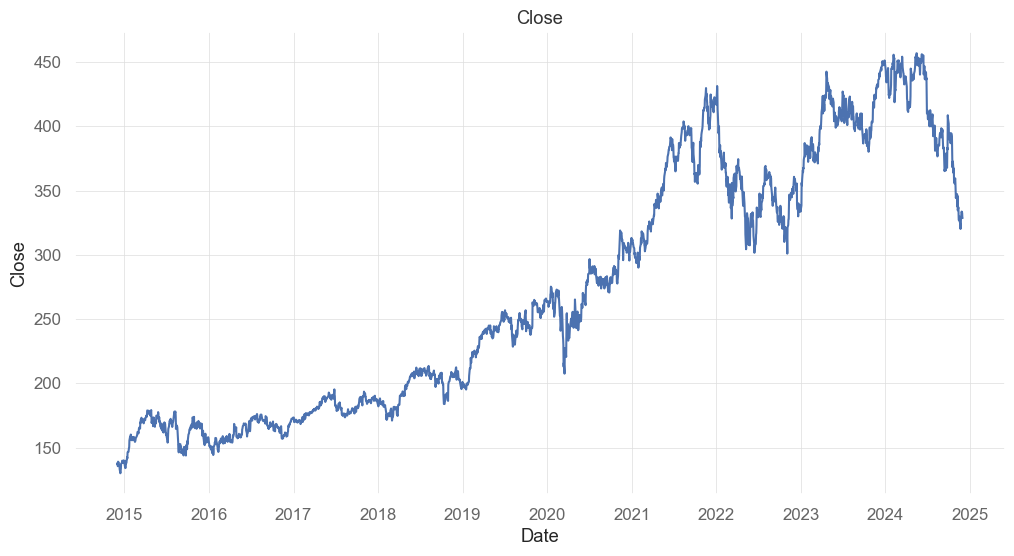

In [7]:
Analysis.plot_data_by_column('Close')

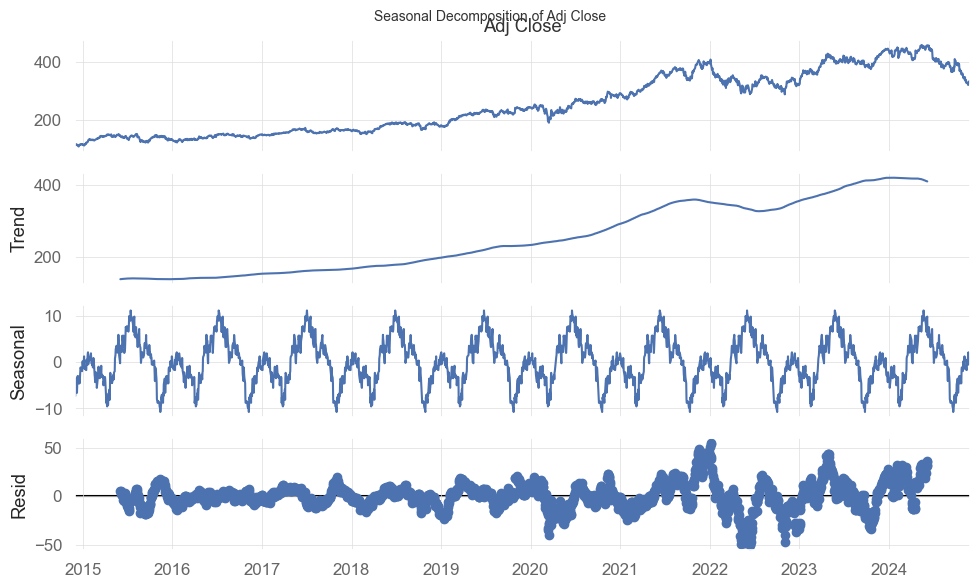

In [8]:
Analysis.seasonal_decomposition('Adj Close')

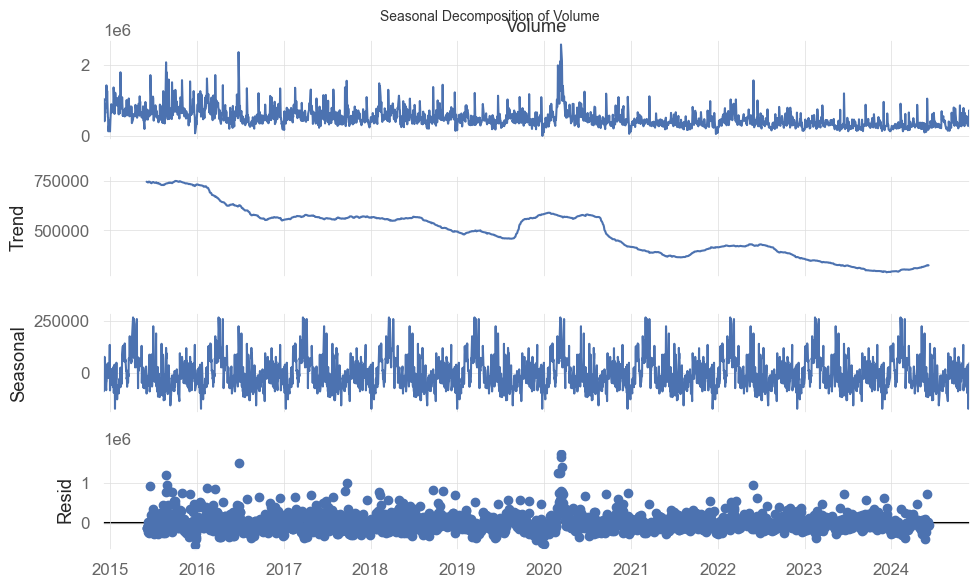

In [9]:
Analysis.seasonal_decomposition('Volume')

Feature Engineering

Generating Cross Asset Features

In [10]:
CrossAssetFeatures = CrossAssetFeatureEngineering(tickers, start_date, end_date)

In [11]:
CrossAssetFeatures.download_data()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [12]:
CrossAssetFeatures.align_data()

In [13]:
CrossAssetFeatures.calculate_features()

In [14]:
CrossAssetFeatures.save_features("loreal_cross_asset_features.csv")

Features saved to loreal_cross_asset_features.csv


Generating Technical, Fundamental, Decomposed, Recurrance Features to create the full feature set

In [15]:
data_path = "merged_df_final.csv"
cross_asset_path = "loreal_cross_asset_features.csv"
unwanted_columns = ['EOM_14_100000000', 'QQEl_14_5_4.236', 'QQEs_14_5_4.236', 'PSARl_0.02_0.2', 'PSARs_0.02_0.2', 'PSARaf_0.02_0.2','HILOs_13_21','HILOl_13_21', 'PSARr_0.02_0.2', 'SUPERTl_7_3.0', 'SUPERTs_7_3.0', 'SUPERTd_7_3.0','SUPERT_7_3.0', 'ZIGZAGs_5.0%_10', 'ZIGZAGv_5.0%_10', 'ZIGZAGd_5.0%_10', 'VIDYA_14', 'VHM_610', 'PVIe_255', 'Rolling_Volatility_1'
                   ]
output_path_features = 'features_df_prefeatselect.csv'
output_path_transformed = "pca_output"

In [16]:
FeatureEngineeringSet = FeatureEngineering(data_path)

Feature Selection:
- Using multicollinearity filtering & PCA to reduce dimensionality
- PCA transformed features were analysed for high skewness and kurtosis - transformations were applied

Data loaded successfully with shape (2562, 12)
Added technical indicators
Added valuation ratios and financial health metrics
'Close' Data normalized for Recurrence Properties
Added recurrence features
Added decomposed features
Merged cross-asset features
Added lagged features
Dropped unwanted columns
Handled missing values
Shifted label for next day's movement
Features saved to features_df_prefeatselect.csv
Initial number of features: 380


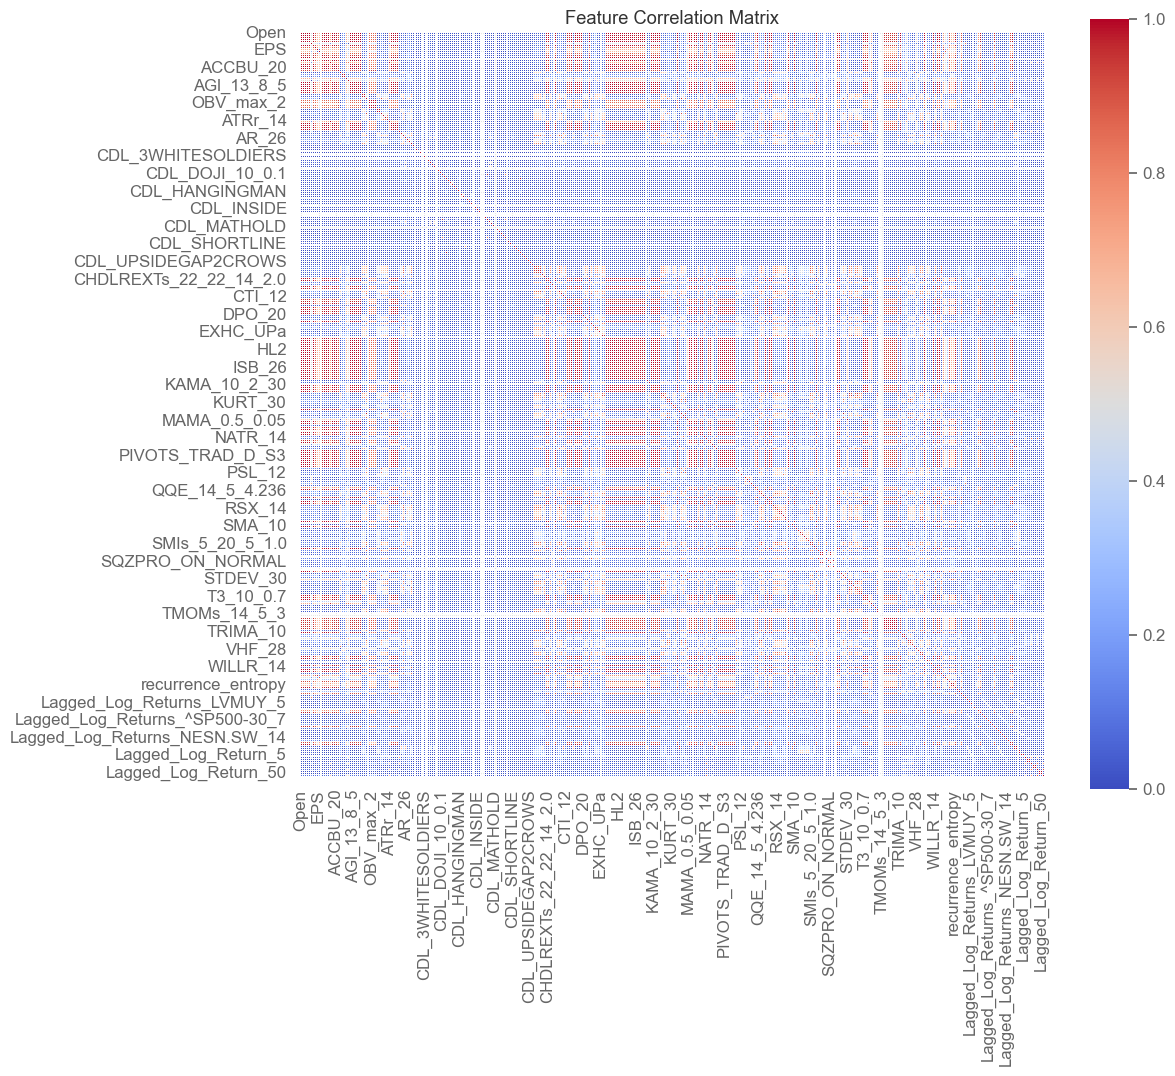

Number of highly correlated feature pairs: 12658
Features dropped due to high correlation and low importance: ['TOS_STDEVALL_L_3', 'PIVOTS_TRAD_D_R1', 'D_9_3', 'ZL_EMA_10', 'SMMA_7', 'CHDLREXTs_22_22_14_2.0', 'T3_10_0.7', 'STCmacd_10_12_26_0.5', 'REMAP_0.0_100.0_-1.0_1.0', 'DEC_1', 'ALPHATl_14_1_50_2', 'CKSPs_10_3_20', 'STOCHFd_14_3', 'ABER_XG_5_15', 'HA_close', 'Lagged_Return_14', 'RVGIs_14_4', 'AMATe_SR_8_21_2', 'PriceToCash', 'VWAP_D', 'APO_12_26', 'HILO_13_21', 'CHDLREXTl_22_22_14_2.0', 'SSF3_20', 'SMA_10', 'OHLC4', 'RSI_14', 'MACD_12_26_9', 'PWMA_10', 'TRENDFLEX_20_20_0.04', 'PE_to_Dividend', 'OBV_max_2', 'Low', 'ICS_26', 'TEMA_10', 'INVFISHER_1.0', 'VWMA_10', 'BBM_5_2.0', 'HL2', 'QQE_14_5_4.236', 'AO_5_34', 'Rolling_Volatility_50', 'OBVe_12', 'INC_1', 'OBV', 'PIVOTS_TRAD_D_S1', 'VTXP_14', 'ALPHAT_14_1_50', 'SQZPRO_20_2.0_20_2.0_1.5_1.0', 'PIVOTS_TRAD_D_R2', 'SINWMA_14', 'Lagged_Return_28', 'PriceToBook', 'VAR_30', 'Adj Close', 'IKS_26', 'high_Z_30_1', 'PIVOTS_TRAD_D_S3', 'TRIMA_1

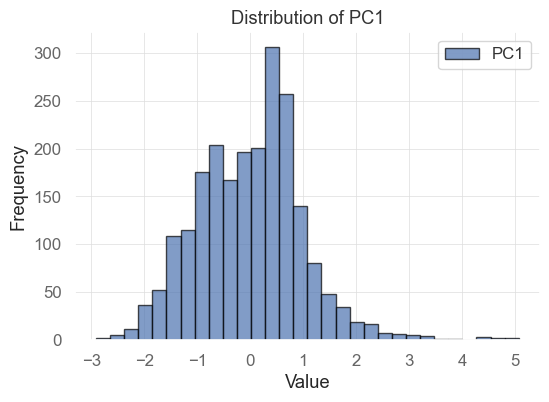

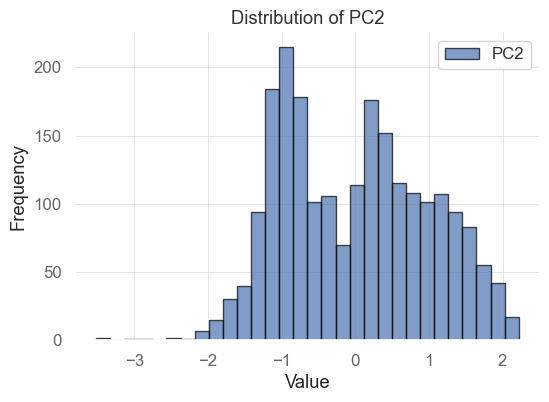

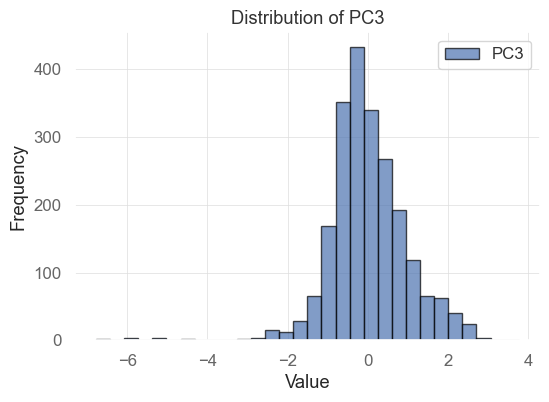

PCA-transformed data and target saved in pca_output


In [17]:
FeatureEngineeringSet.run(cross_asset_path, unwanted_columns, output_path_features, output_path_transformed)

In [18]:
LSTM = LSTMModel()

Trial 20 Complete [00h 00m 22s]
val_accuracy: 0.5404699444770813

Best val_accuracy So Far: 0.5535247921943665
Total elapsed time: 00h 04m 04s
Best Validation Accuracy: 0.5535247921943665
Best Hyperparameters: {'units1': 16, 'units2': 8, 'units3': 8, 'Dropout_rate1': 0.0, 'Dropout_rate2': 0.0, 'activation1': 'elu', 'activation2': 'relu', 'activation3': 'tanh', 'learning_rate': 0.0001, 'batch_size': 64}
Epoch 1/50
13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4944 - loss: 0.6943 - precision: 0.5089 - recall: 0.1957
Epoch 1: loss improved from inf to 0.69457, saving model to optimized_lstm_model.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.4929 - loss: 0.6944 - precision: 0.5101 - recall: 0.2092 - val_accuracy: 0.4883 - val_loss: 0.6914 - val_precision: 0.5000 - val_recall: 0.6684
Epoch 2/50
13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4899 - loss: 0.6941 - precision: 0.5017 - recall: 0.2766
Epoch 2: loss improved from 0.69457 to 0.69423, saving model to o

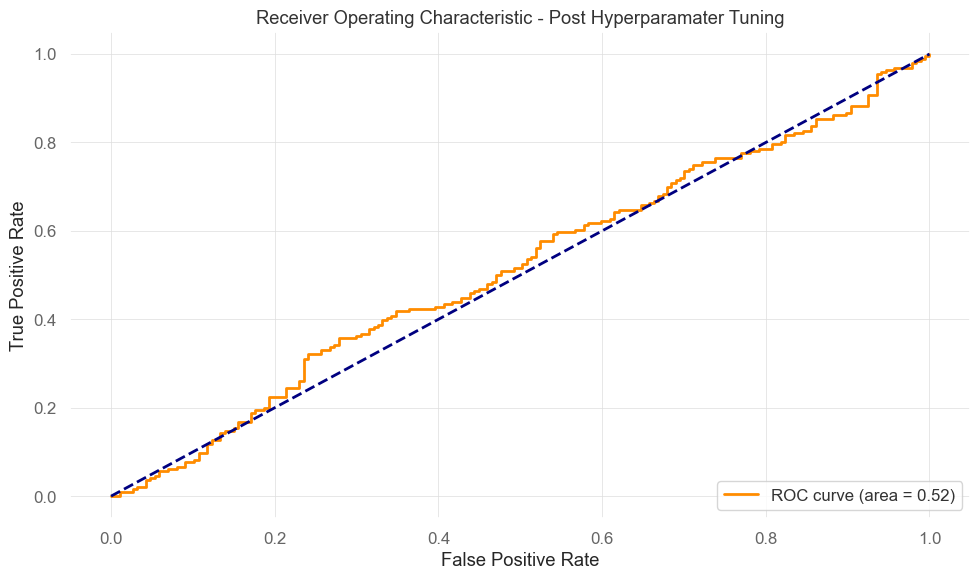

Predictions saved to aligned_data.csv


In [19]:
LSTM.run(tuner_type='random')

In [20]:
file_path = "aligned_data.csv"
commission = 0.002
starting_cash = 10000
position_size = 1.0

In [21]:
LSTMTradingStrategy = LSTMTradingStrategyBacktest(file_path, commission, starting_cash, position_size)

Data loaded successfully.


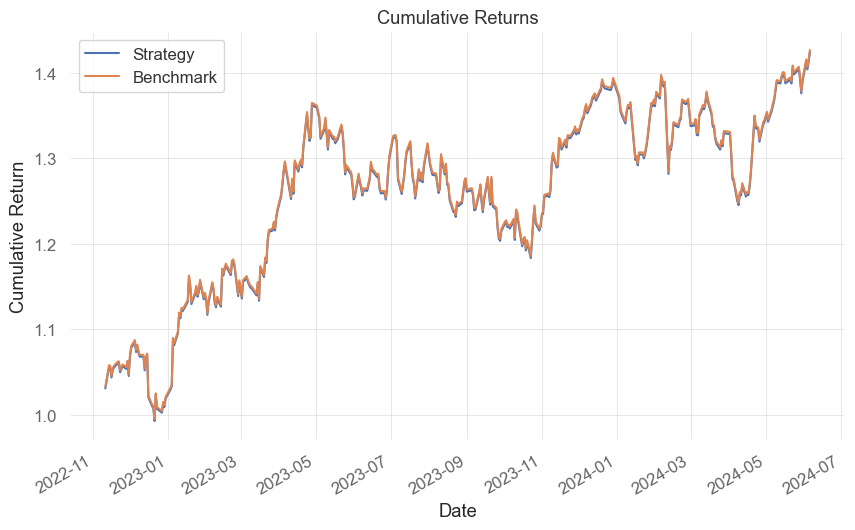

In [22]:
LSTMTradingStrategy.run_backtest()